<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/chexpert_adi_k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SETUP

In [1]:
!pip install -q kagglehub
import os

In [2]:
os.environ["KAGGLE_USERNAME"] = "lawdenbhojyam"
os.environ["KAGGLE_KEY"] = "a"

In [3]:
!pip install -q kaggle
!kaggle datasets list -s chexpert | head

ref                                                    title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
ashery/chexpert                                        CheXpert-v1.0-small                      11496130509  2021-04-28 11:38:12.103000          28477         59  0.7647059        
mimsadiislam/chexpert                                  CheXpert                                 11505076821  2020-11-04 22:23:11.013000           4805         26  0.1764706        
willarevalo/chexpert-v10-small                         CheXpert_v1.0_small                      11505076821  2020-09-16 19:32:55.187000          15437         13  0.1764706        
amritpal333/chexpert-train-csv-modified                Chexpert Train csv modified             

In [4]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.8/256.8 kB 4.1 MB/s eta 0:00:00


In [5]:
!kaggle datasets download -d ashery/chexpert


Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
100% 10.7G/10.7G [08:08<00:00, 23.5MB/s]



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [7]:
!ls -lh /content

total 11G
-rw-r--r-- 1 root root  11G Apr 28  2021 chexpert.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [8]:
!du -sh /content/chexpert.zip

11G	/content/chexpert.zip


In [9]:
!unzip -q /content/chexpert.zip -d /content/chexpert

In [10]:
!ls /content/chexpert

train  train.csv  valid  valid.csv


#BASIC

In [11]:
train_df = pd.read_csv("/content/chexpert/train.csv")
valid_df = pd.read_csv("/content/chexpert/valid.csv")

In [12]:
print(train_df.shape)
print(valid_df.shape)

train_df.head()

(223414, 19)
(234, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/view1_frontal.jpg,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/view1_frontal.jpg,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/view2_lateral.jpg,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/view1_frontal.jpg,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [13]:
DATASET_PATH = "/content/chexpert"

TRAIN_CSV = os.path.join(DATASET_PATH, "train.csv")
VALID_CSV = os.path.join(DATASET_PATH, "valid.csv")

print(TRAIN_CSV)
print(VALID_CSV)

/content/chexpert/train.csv
/content/chexpert/valid.csv


In [14]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print("Train Loaded Successfully")
print("Validation Loaded Successfully")

Train Loaded Successfully
Validation Loaded Successfully


In [15]:
print("TRAIN DATASET")
print("Rows :", train_df.shape[0])
print("Columns :", train_df.shape[1])
print("VALID DATASET")
print("Rows :", valid_df.shape[0])
print("Columns :", valid_df.shape[1])

TRAIN DATASET
Rows : 223414
Columns : 19
VALID DATASET
Rows : 234
Columns : 19


In [16]:
train_df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/view1_frontal.jpg,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/view1_frontal.jpg,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/view2_lateral.jpg,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/view1_frontal.jpg,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [17]:
train_df.sample(5, random_state=42)

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
305,CheXpert-v1.0-small/train/patient00082/study1/view1_frontal.jpg,Male,18,Frontal,PA,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
151324,CheXpert-v1.0-small/train/patient35759/study9/view1_frontal.jpg,Male,90,Frontal,AP,NaN,NaN,1.0,NaN,NaN,1.0,-1.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0
19284,CheXpert-v1.0-small/train/patient04789/study1/view2_lateral.jpg,Male,39,Lateral,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
165026,CheXpert-v1.0-small/train/patient38491/study5/view1_frontal.jpg,Male,60,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
26786,CheXpert-v1.0-small/train/patient06537/study3/view1_frontal.jpg,Female,66,Frontal,AP,NaN,NaN,0.0,1.0,NaN,NaN,0.0,-1.0,-1.0,0.0,0.0,NaN,NaN,NaN


In [18]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223414 entries, 0 to 223413
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Path                        223414 non-null  object 
 1   Sex                         223414 non-null  object 
 2   Age                         223414 non-null  int64  
 3   Frontal/Lateral             223414 non-null  object 
 4   AP/PA                       191027 non-null  object 
 5   No Finding                  22381 non-null   float64
 6   Enlarged Cardiomediastinum  44839 non-null   float64
 7   Cardiomegaly                46203 non-null   float64
 8   Lung Opacity                117778 non-null  float64
 9   Lung Lesion                 11944 non-null   float64
 10  Edema                       85956 non-null   float64
 11  Consolidation               70622 non-null   float64
 12  Pneumonia                   27608 non-null   float64
 13  Atelectasis   

In [19]:
for i,col in enumerate(train_df.columns):
    print(f"{i+1}. {col}")

1. Path
2. Sex
3. Age
4. Frontal/Lateral
5. AP/PA
6. No Finding
7. Enlarged Cardiomediastinum
8. Cardiomegaly
9. Lung Opacity
10. Lung Lesion
11. Edema
12. Consolidation
13. Pneumonia
14. Atelectasis
15. Pneumothorax
16. Pleural Effusion
17. Pleural Other
18. Fracture
19. Support Devices


In [20]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,223414.0,60.430653,17.820925,0.0,49.0,62.0,74.0,90.0
No Finding,22381.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Enlarged Cardiomediastinum,44839.0,-0.035795,0.718442,-1.0,-1.0,0.0,0.0,1.0
Cardiomegaly,46203.0,0.409346,0.769323,-1.0,0.0,1.0,1.0,1.0
Lung Opacity,117778.0,0.848911,0.472571,-1.0,1.0,1.0,1.0,1.0
Lung Lesion,11944.0,0.644508,0.691607,-1.0,1.0,1.0,1.0,1.0
Edema,85956.0,0.456769,0.741785,-1.0,0.0,1.0,1.0,1.0
Consolidation,70622.0,-0.183498,0.753980,-1.0,-1.0,0.0,0.0,1.0
Pneumonia,27608.0,-0.461134,0.828249,-1.0,-1.0,-1.0,0.0,1.0
Atelectasis,68443.0,-0.005304,0.990244,-1.0,-1.0,0.0,1.0,1.0


In [21]:
train_df.describe(include="object").T

,count,unique,top,freq
Path,223414,223414,CheXpert-v1.0-small/train/patient64540/study1/view1_frontal.jpg,1
Sex,223414,3,Male,132636
Frontal/Lateral,223414,2,Frontal,191027
AP/PA,191027,4,AP,161590


In [22]:
missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]
missing

,0
Pleural Other,216922
Lung Lesion,211470
Fracture,211220
No Finding,201033
Pneumonia,195806
Enlarged Cardiomediastinum,178575
Cardiomegaly,177211
Atelectasis,154971
Consolidation,152792
Pneumothorax,144480


In [23]:
train_df["Path"].head(10)

,Path
0,CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg
1,CheXpert-v1.0-small/train/patient00002/study2/view1_frontal.jpg
2,CheXpert-v1.0-small/train/patient00002/study1/view1_frontal.jpg
3,CheXpert-v1.0-small/train/patient00002/study1/view2_lateral.jpg
4,CheXpert-v1.0-small/train/patient00003/study1/view1_frontal.jpg
5,CheXpert-v1.0-small/train/patient00004/study1/view1_frontal.jpg
6,CheXpert-v1.0-small/train/patient00004/study1/view2_lateral.jpg
7,CheXpert-v1.0-small/train/patient00005/study1/view1_frontal.jpg
8,CheXpert-v1.0-small/train/patient00005/study1/view2_lateral.jpg
9,CheXpert-v1.0-small/train/patient00005/study2/view1_frontal.jpg


In [24]:
train_df["Path"] = train_df["Path"].str.replace(
    "CheXpert-v1.0-small/",
    "",
    regex=False
)

valid_df["Path"] = valid_df["Path"].str.replace(
    "CheXpert-v1.0-small/",
    "",
    regex=False
)

In [25]:
ROOT = "/content/chexpert"

train_df["image_path"] = train_df["Path"].apply(
    lambda x: os.path.join(ROOT, x)
)

valid_df["image_path"] = valid_df["Path"].apply(
    lambda x: os.path.join(ROOT, x)
)

In [26]:
print(train_df["image_path"].head())

print(train_df["image_path"].apply(os.path.exists).value_counts())

0    /content/chexpert/train/patient00001/study1/view1_frontal.jpg
1    /content/chexpert/train/patient00002/study2/view1_frontal.jpg
2    /content/chexpert/train/patient00002/study1/view1_frontal.jpg
3    /content/chexpert/train/patient00002/study1/view2_lateral.jpg
4    /content/chexpert/train/patient00003/study1/view1_frontal.jpg
Name: image_path, dtype: object
image_path
True    223414
Name: count, dtype: int64


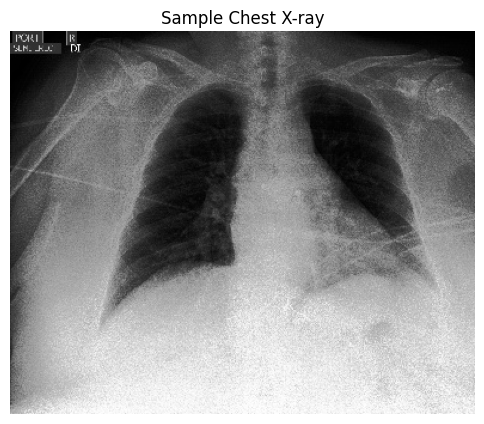

In [27]:
from PIL import Image
sample_path = train_df.iloc[0]["image_path"]
img = Image.open(sample_path)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Sample Chest X-ray")
plt.show()

#EDA

In [28]:
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(train_df)) * 100
})

display(missing_df)

,Missing Count,Missing %
Pleural Other,216922,97.094184
Lung Lesion,211470,94.653871
Fracture,211220,94.541971
No Finding,201033,89.982275
Pneumonia,195806,87.642672
Enlarged Cardiomediastinum,178575,79.930085
Cardiomegaly,177211,79.319559
Atelectasis,154971,69.364946
Consolidation,152792,68.389626
Pneumothorax,144480,64.669179


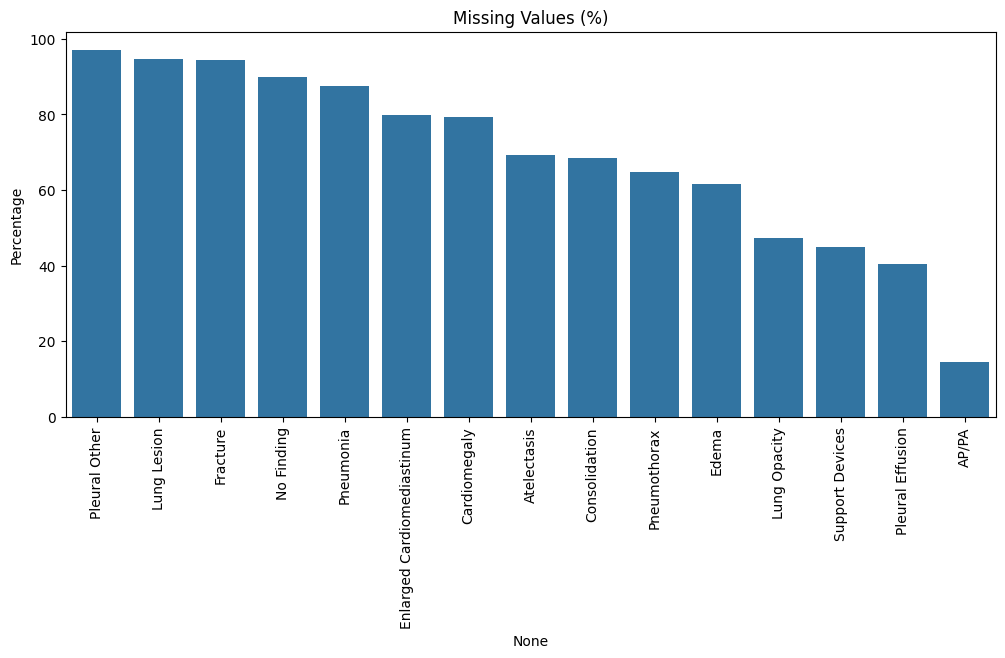

In [29]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Missing %"]
)

plt.xticks(rotation=90)
plt.title("Missing Values (%)")
plt.ylabel("Percentage")
plt.show()

In [30]:
print("Duplicate Paths :", train_df["Path"].duplicated().sum())
print("Unique Patients :", train_df["Path"].str.extract(r'(patient\d+)')[0].nunique())

Duplicate Paths : 0
Unique Patients : 64540


In [31]:
train_df["Sex"].value_counts(dropna=False)

,count
Sex,
Male,132636
Female,90777
Unknown,1


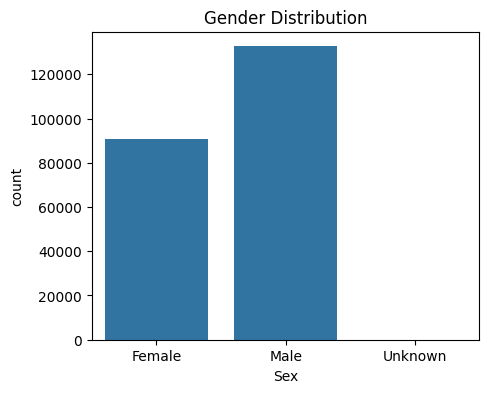

In [32]:
plt.figure(figsize=(5,4))
sns.countplot(data=train_df,x="Sex")
plt.title("Gender Distribution")
plt.show()

In [33]:
train_df["Age"].describe()

,Age
count,223414.000000
mean,60.430653
std,17.820925
min,0.000000
25%,49.000000
50%,62.000000
75%,74.000000
max,90.000000


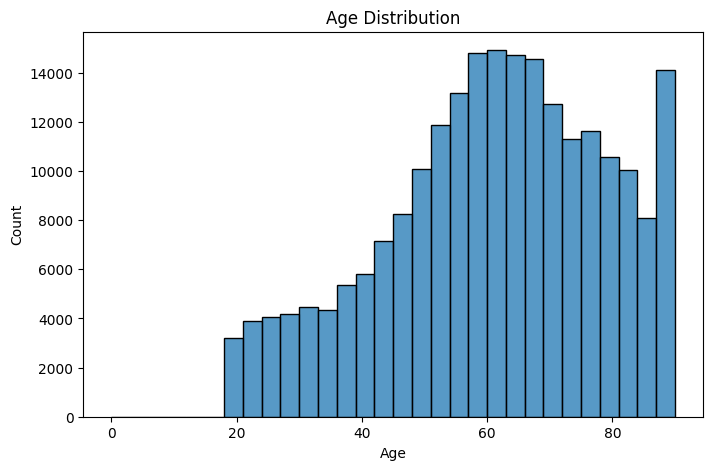

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["Age"],bins=30)
plt.title("Age Distribution")
plt.show()

In [35]:
train_df["AP/PA"].value_counts(dropna=False)

,count
AP/PA,
AP,161590
NaN,32387
PA,29420
LL,16
RL,1


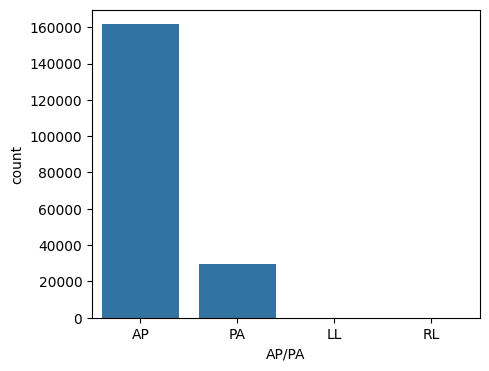

In [36]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=train_df,
    x="AP/PA"
)

plt.show()

In [37]:
train_df["Frontal/Lateral"].value_counts(dropna=False)

,count
Frontal/Lateral,
Frontal,191027
Lateral,32387


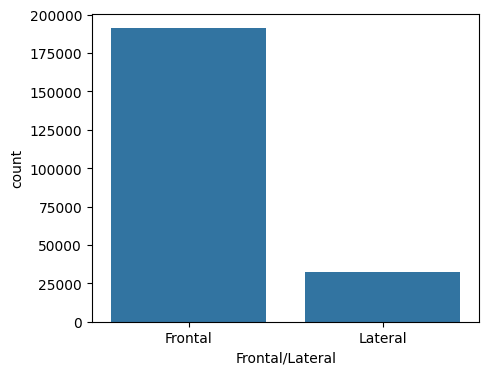

In [38]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=train_df,
    x="Frontal/Lateral"
)

plt.show()

In [39]:
label_cols = train_df.columns[5:]
print(label_cols)

Index(['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
       'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia',
       'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other',
       'Fracture', 'Support Devices', 'image_path'],
      dtype='object')


In [40]:
positive_counts = (train_df[label_cols] == 1).sum()
positive_counts.sort_values(ascending=False)

,0
Support Devices,116001
Lung Opacity,105581
Pleural Effusion,86187
Edema,52246
Atelectasis,33376
Cardiomegaly,27000
No Finding,22381
Pneumothorax,19448
Consolidation,14783
Enlarged Cardiomediastinum,10798


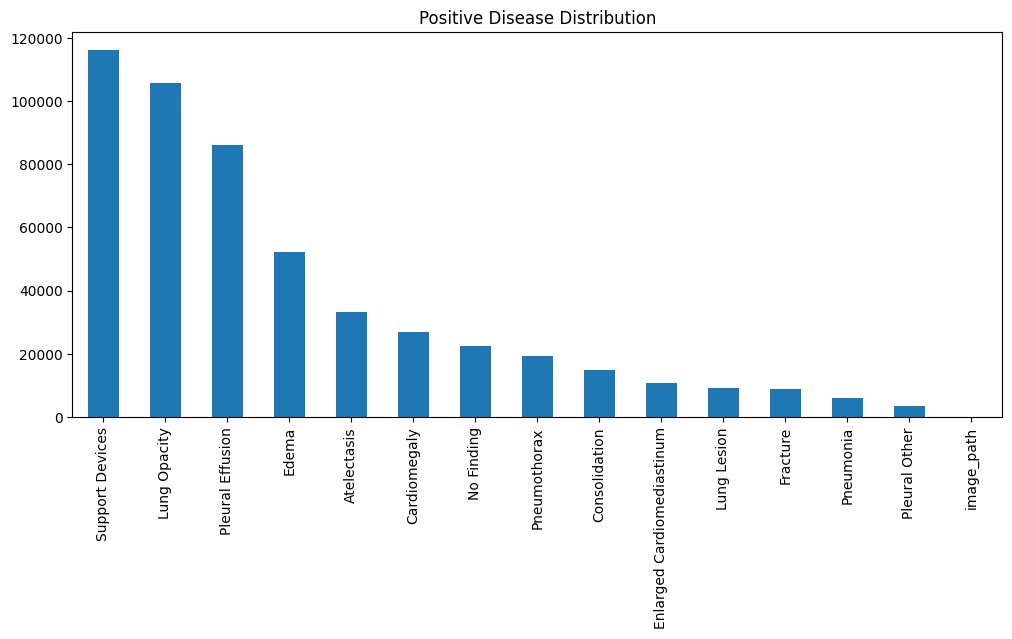

In [41]:
positive_counts = positive_counts.sort_values(ascending=False)
plt.figure(figsize=(12,5))
positive_counts.plot(kind="bar")
plt.title("Positive Disease Distribution")
plt.show()

In [42]:
uncertain = (train_df[label_cols] == -1).sum()
uncertain.sort_values(ascending=False)

,0
Atelectasis,33739
Consolidation,27742
Pneumonia,18770
Edema,12984
Enlarged Cardiomediastinum,12403
Pleural Effusion,11628
Cardiomegaly,8087
Lung Opacity,5598
Pneumothorax,3145
Pleural Other,2653


In [43]:
train_df["No Finding"].value_counts()

,count
No Finding,
1.0,22381


In [44]:
train_df["num_positive_labels"] = (train_df[label_cols] == 1).sum(axis=1)

train_df["num_positive_labels"].describe()

,num_positive_labels
count,223414.000000
mean,2.307774
std,1.245450
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,8.000000


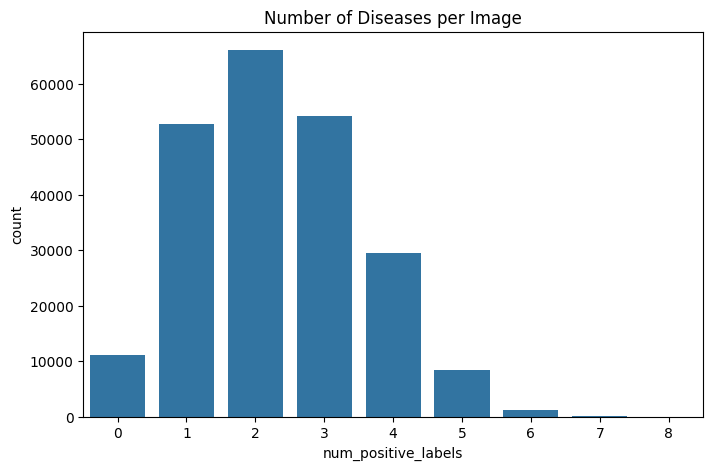

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=train_df["num_positive_labels"]
)

plt.title("Number of Diseases per Image")

plt.show()

In [46]:
label_cols = [
    "No Finding",
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices"
]

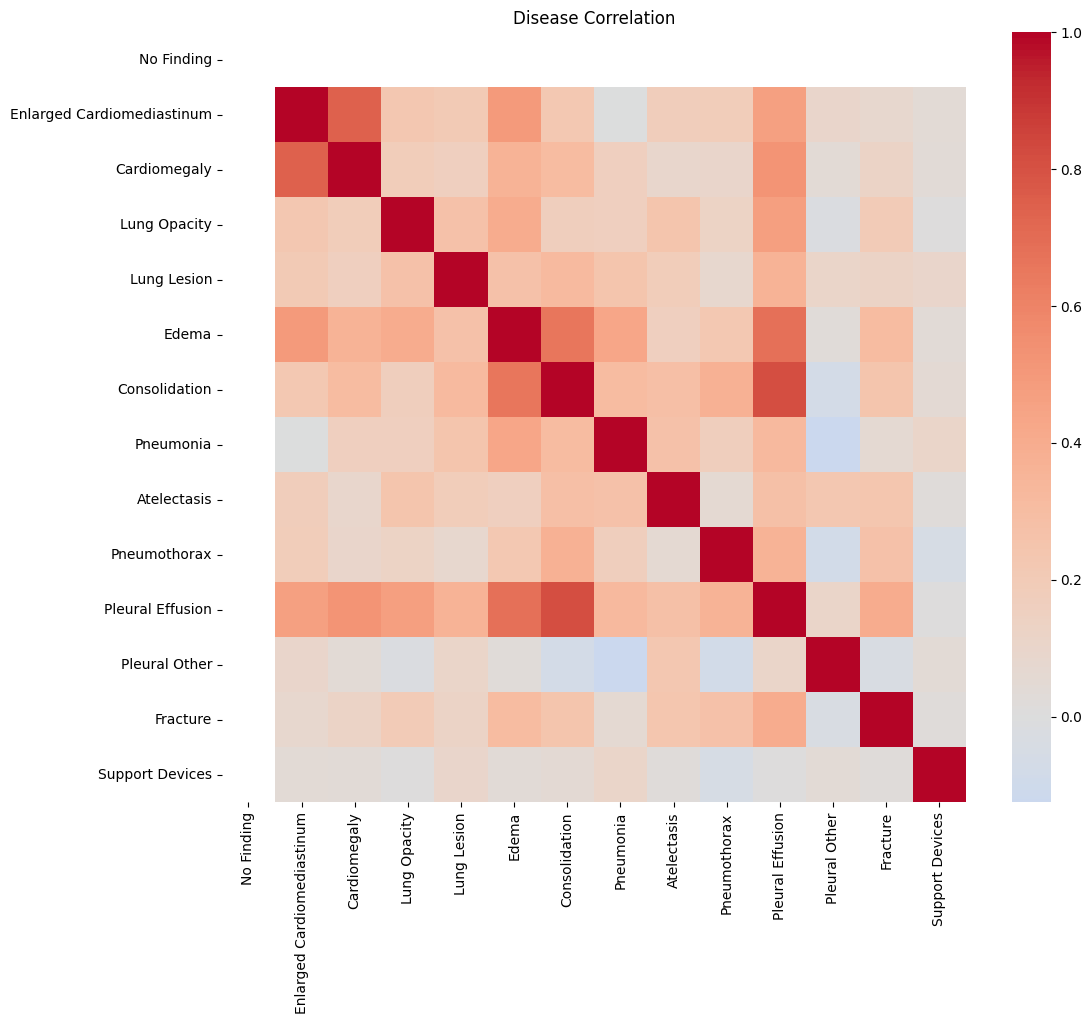

In [47]:
corr = train_df[label_cols].replace(-1,np.nan).corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Disease Correlation")

plt.show()

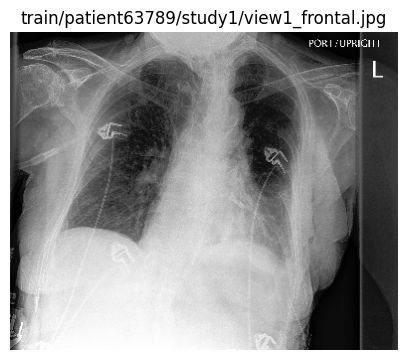

In [48]:
from PIL import Image

sample = train_df.sample(1)

img = Image.open(sample.iloc[0]["image_path"])

plt.figure(figsize=(5,5))

plt.imshow(img,cmap="gray")

plt.axis("off")

plt.title(sample.iloc[0]["Path"])

plt.show()

In [49]:
sample[label_cols].T

,222583
No Finding,NaN
Enlarged Cardiomediastinum,NaN
Cardiomegaly,NaN
Lung Opacity,1.0
Lung Lesion,NaN
Edema,NaN
Consolidation,NaN
Pneumonia,NaN
Atelectasis,NaN
Pneumothorax,0.0


In [50]:
train_df[label_cols].dtypes

,0
No Finding,float64
Enlarged Cardiomediastinum,float64
Cardiomegaly,float64
Lung Opacity,float64
Lung Lesion,float64
Edema,float64
Consolidation,float64
Pneumonia,float64
Atelectasis,float64
Pneumothorax,float64


In [51]:
print("Total Images :",len(train_df))

print("Unique Patients :",train_df["Path"].str.extract(r'(patient\d+)')[0].nunique())

print("Average Age :",train_df["Age"].mean())

print("Male :",train_df["Sex"].value_counts().get("Male",0))

print("Female :",train_df["Sex"].value_counts().get("Female",0))

Total Images : 223414
Unique Patients : 64540
Average Age : 60.430653405784774
Male : 132636
Female : 90777


#Data Preprocessing

In [52]:
#train_df = train_df[train_df["image_exists"]].reset_index(drop=True)
#valid_df = valid_df[valid_df["image_exists"]].reset_index(drop=True)

#print(train_df.shape)
#print(valid_df.shape)

In [53]:
train_df[label_cols].isnull().sum()

,0
No Finding,201033
Enlarged Cardiomediastinum,178575
Cardiomegaly,177211
Lung Opacity,105636
Lung Lesion,211470
Edema,137458
Consolidation,152792
Pneumonia,195806
Atelectasis,154971
Pneumothorax,144480


In [54]:
train_df[label_cols] = train_df[label_cols].fillna(0)
valid_df[label_cols] = valid_df[label_cols].fillna(0)

In [55]:
train_df[label_cols] = train_df[label_cols].replace(-1,0)
valid_df[label_cols] = valid_df[label_cols].replace(-1,0)

In [56]:
train_df[label_cols] = train_df[label_cols].astype(int)
valid_df[label_cols] = valid_df[label_cols].astype(int)

In [57]:
for col in label_cols:
    print(col, sorted(train_df[col].unique()))

No Finding [np.int64(0), np.int64(1)]
Enlarged Cardiomediastinum [np.int64(0), np.int64(1)]
Cardiomegaly [np.int64(0), np.int64(1)]
Lung Opacity [np.int64(0), np.int64(1)]
Lung Lesion [np.int64(0), np.int64(1)]
Edema [np.int64(0), np.int64(1)]
Consolidation [np.int64(0), np.int64(1)]
Pneumonia [np.int64(0), np.int64(1)]
Atelectasis [np.int64(0), np.int64(1)]
Pneumothorax [np.int64(0), np.int64(1)]
Pleural Effusion [np.int64(0), np.int64(1)]
Pleural Other [np.int64(0), np.int64(1)]
Fracture [np.int64(0), np.int64(1)]
Support Devices [np.int64(0), np.int64(1)]


In [58]:
print("Before:",len(train_df))
train_df = train_df.drop_duplicates(subset="Path").reset_index(drop=True)
print("After :",len(train_df))

Before: 223414
After : 223414


In [59]:
train_df["patient_id"] = train_df["Path"].str.extract(r'(patient\d+)')
valid_df["patient_id"] = valid_df["Path"].str.extract(r'(patient\d+)')

In [60]:
bad_images=[]
for path in train_df["image_path"]:
    try:
        Image.open(path).verify()
    except:
        bad_images.append(path)
print("Bad Images:",len(bad_images))

Bad Images: 0


In [61]:
train_df = train_df[
    ~train_df["image_path"].isin(bad_images)
].reset_index(drop=True)

In [62]:
train_df["split"]="train"
valid_df["split"]="valid"

In [63]:
train_df["num_labels"]=train_df[label_cols].sum(axis=1)
valid_df["num_labels"]=valid_df[label_cols].sum(axis=1)

In [64]:
mask = (train_df["num_labels"]==0)
print(mask.sum())

11141


In [65]:
final_columns = [
    "image_path",
    "Path",
    "patient_id",
    "Sex",
    "Age",
    "AP/PA",
    "Frontal/Lateral"
] + label_cols

train_clean = train_df[final_columns]
valid_clean = valid_df[final_columns]

In [66]:
print(train_clean.shape)
display(train_clean.head())
train_clean.info()

(223414, 21)


,image_path,Path,patient_id,Sex,Age,AP/PA,Frontal/Lateral,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,/content/chexpert/train/patient00001/study1/view1_frontal.jpg,train/patient00001/study1/view1_frontal.jpg,patient00001,Female,68,AP,Frontal,1,0,0,0,0,0,0,0,0,0,0,0,0,1
1,/content/chexpert/train/patient00002/study2/view1_frontal.jpg,train/patient00002/study2/view1_frontal.jpg,patient00002,Female,87,AP,Frontal,0,0,0,1,0,0,0,0,0,0,0,0,1,0
2,/content/chexpert/train/patient00002/study1/view1_frontal.jpg,train/patient00002/study1/view1_frontal.jpg,patient00002,Female,83,AP,Frontal,0,0,0,1,0,0,0,0,0,0,0,0,1,0
3,/content/chexpert/train/patient00002/study1/view2_lateral.jpg,train/patient00002/study1/view2_lateral.jpg,patient00002,Female,83,NaN,Lateral,0,0,0,1,0,0,0,0,0,0,0,0,1,0
4,/content/chexpert/train/patient00003/study1/view1_frontal.jpg,train/patient00003/study1/view1_frontal.jpg,patient00003,Male,41,AP,Frontal,0,0,0,0,0,1,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223414 entries, 0 to 223413
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   image_path                  223414 non-null  object
 1   Path                        223414 non-null  object
 2   patient_id                  223414 non-null  object
 3   Sex                         223414 non-null  object
 4   Age                         223414 non-null  int64 
 5   AP/PA                       191027 non-null  object
 6   Frontal/Lateral             223414 non-null  object
 7   No Finding                  223414 non-null  int64 
 8   Enlarged Cardiomediastinum  223414 non-null  int64 
 9   Cardiomegaly                223414 non-null  int64 
 10  Lung Opacity                223414 non-null  int64 
 11  Lung Lesion                 223414 non-null  int64 
 12  Edema                       223414 non-null  int64 
 13  Consolidation               2

In [67]:
train_clean.to_csv(
    "/content/train_clean.csv",index=False)
valid_clean.to_csv(
    "/content/valid_clean.csv",index=False)
print("Saved Successfully")

Saved Successfully


In [68]:
(train_clean[label_cols]==1).sum().sort_values(ascending=False)

,0
Support Devices,116001
Lung Opacity,105581
Pleural Effusion,86187
Edema,52246
Atelectasis,33376
Cardiomegaly,27000
No Finding,22381
Pneumothorax,19448
Consolidation,14783
Enlarged Cardiomediastinum,10798


In [69]:
print("Images :",len(train_clean))
print("Patients :",train_clean["patient_id"].nunique())
print("Image Exists :",train_clean["image_path"].apply(os.path.exists).all())
print("Missing Labels :",train_clean[label_cols].isnull().sum().sum())

Images : 223414
Patients : 64540
Image Exists : True
Missing Labels : 0


#Biomed

In [70]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [71]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

In [72]:
class CheXpertDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:

            image = self.transform(image)

        labels = torch.tensor(
            row[label_cols].values.astype("float32")
        )

        return image, labels

In [73]:
train_dataset = CheXpertDataset(
    train_clean,
    train_transform
)

valid_dataset = CheXpertDataset(
    valid_clean,
    val_transform
)

In [74]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [75]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 14])


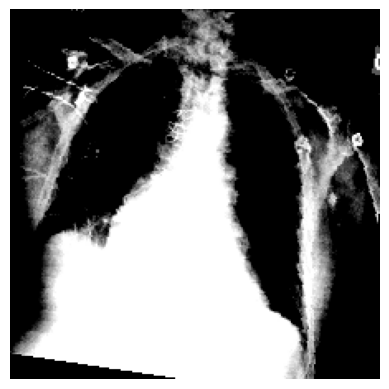

tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.])


In [76]:
plt.imshow(
    images[0].permute(1,2,0)
)
plt.axis("off")
plt.show()

print(labels[0])

In [77]:
!pip install -q open_clip_torch transformers timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [78]:
import torch.nn as nn
import open_clip
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [79]:
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms("hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
tokenizer = open_clip.get_tokenizer("hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  784MB            

open_clip_pytorch_model.bin: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

In [80]:
model = model.to(device)
dummy = torch.randn(2,3,224,224).to(device)
with torch.no_grad():
    features = model.encode_image(dummy)

print(features.shape)

torch.Size([2, 512])


In [81]:
FEATURE_DIM = features.shape[1]

print(FEATURE_DIM)

512


In [82]:
print(model)

CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
          

In [83]:
classifier = nn.Sequential(
    nn.Linear(FEATURE_DIM,512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512,256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256,14)
)

In [84]:
class BioMedCLIPClassifier(nn.Module):
    def __init__(self,clip_model,classifier):
        super().__init__()
        self.clip_model=clip_model
        self.classifier=classifier

    def forward(self,x):
        features=self.clip_model.encode_image(x)
        logits=self.classifier(features)
        return logits

In [85]:
net=BioMedCLIPClassifier(model,classifier)
net=net.to(device)

In [86]:
for param in net.clip_model.parameters():
    param.requires_grad=False

In [87]:
for name,param in net.clip_model.visual.named_parameters():
    if "blocks.10" in name or "blocks.11" in name:
        param.requires_grad=True

In [88]:
total=sum(p.numel() for p in net.parameters())
trainable=sum(
    p.numel()
    for p in net.parameters()
    if p.requires_grad)
print(total)
print(trainable)

196300303
14573326


In [89]:
images,labels=next(iter(train_loader))
images=images.to(device)
outputs=net(images)
print(outputs.shape)

torch.Size([32, 14])


In [90]:
print(net)

BioMedCLIPClassifier(
  (clip_model): CustomTextCLIP(
    (visual): TimmModel(
      (trunk): VisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
          (norm): Identity()
        )
        (pos_drop): Dropout(p=0.0, inplace=False)
        (patch_drop): Identity()
        (norm_pre): Identity()
        (blocks): Sequential(
          (0): Block(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (attn): Attention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (q_norm): Identity()
              (k_norm): Identity()
              (attn_drop): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (proj): Linear(in_features=768, out_features=768, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): Identity()
            (drop_path1): Identity()
            (norm2): 

In [91]:
positive = train_clean[label_cols].sum()

negative = len(train_clean) - positive

pos_weight = torch.tensor(
    (negative / positive).values,
    dtype=torch.float32
).to(device)

print(pos_weight)

tensor([ 8.9823, 19.6903,  7.2746,  1.1160, 23.3211,  3.2762, 14.1129, 35.9952,
         5.6939, 10.4878,  1.5922, 62.4158, 23.7139,  0.9260])


In [92]:
criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

In [93]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, net.parameters()),
    lr=2e-5,
    weight_decay=1e-4
)

In [94]:
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [95]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

In [96]:
from tqdm import tqdm
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    return running_loss / len(loader)

In [97]:
def validate(model, loader):
    model.eval()
    running_loss = 0
    preds = []
    targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds.append(torch.sigmoid(outputs).cpu())
            targets.append(labels.cpu())

    preds = torch.cat(preds)
    targets = torch.cat(targets)
    return running_loss / len(loader), preds, targets

In [98]:
EPOCHS = 3
best_loss = float("inf")

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(net, train_loader)
    val_loss, preds, targets = validate(net, valid_loader)
    scheduler.step()
    print(f"Epoch {epoch+1}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss : {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(
            net.state_dict(),
            "best_biomedclip_chexpert.pth"
        )

        print("Model Saved")

  0%|          | 0/6982 [00:10<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
net.load_state_dict(torch.load("best_biomedclip_chexpert.pth"))

#Metrics

In [99]:
from sklearn.metrics import (roc_auc_score,f1_score,precision_score,recall_score,accuracy_score,classification_report,confusion_matrix,roc_curve,auc)

In [ ]:
net.load_state_dict(
    torch.load(
        "best_biomedclip_chexpert.pth",
        map_location=device))
net.eval()

BioMedCLIPClassifier(
  (clip_model): CustomTextCLIP(
    (visual): TimmModel(
      (trunk): VisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
          (norm): Identity()
        )
        (pos_drop): Dropout(p=0.0, inplace=False)
        (patch_drop): Identity()
        (norm_pre): Identity()
        (blocks): Sequential(
          (0): Block(
            (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (attn): Attention(
              (qkv): Linear(in_features=768, out_features=2304, bias=True)
              (q_norm): Identity()
              (k_norm): Identity()
              (attn_drop): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (proj): Linear(in_features=768, out_features=768, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): Identity()
            (drop_path1): Identity()
            (norm2): 

In [ ]:
predictions = []
targets = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = net(images)
        probs = torch.sigmoid(outputs)
        predictions.append(probs.cpu())
        targets.append(labels)

predictions = torch.cat(predictions).numpy()
targets = torch.cat(targets).numpy()

In [ ]:
pred_binary = (predictions >= 0.5).astype(int)

In [ ]:
overall_f1 = f1_score(
    targets,
    pred_binary,
    average="macro",
    zero_division=0
)

overall_precision = precision_score(
    targets,
    pred_binary,
    average="macro",
    zero_division=0
)

overall_recall = recall_score(
    targets,
    pred_binary,
    average="macro",
    zero_division=0
)

overall_accuracy = accuracy_score(
    targets.flatten(),
    pred_binary.flatten()
)

print("Accuracy :", overall_accuracy)
print("Macro F1 :", overall_f1)
print("Precision :", overall_precision)
print("Recall :", overall_recall)

Accuracy : 0.7087912087912088
Macro F1 : 0.4169919458294042
Precision : 0.3871432347789679
Recall : 0.6135768785705934


In [ ]:
aurocs = []
for i in range(len(label_cols)):
    try:
        score = roc_auc_score(
            targets[:, i],
            predictions[:, i]
        )
    except:
        score = np.nan
    aurocs.append(score)

In [ ]:
results = pd.DataFrame({
    "Disease": label_cols,
    "AUROC": aurocs
})
display(results)
print()
print("Mean AUROC :", np.nanmean(aurocs))

,Disease,AUROC
0,No Finding,0.905747
1,Enlarged Cardiomediastinum,0.629945
2,Cardiomegaly,0.799167
3,Lung Opacity,0.884259
4,Lung Lesion,0.197425
5,Edema,0.857731
6,Consolidation,0.870496
7,Pneumonia,0.597345
8,Atelectasis,0.765666
9,Pneumothorax,0.754978



Mean AUROC : 0.7566609209418154


In [ ]:
f1s = []
for i in range(len(label_cols)):
    score = f1_score(
        targets[:,i],
        pred_binary[:,i],
        zero_division=0
    )
    f1s.append(score)
results["F1"] = f1s
display(results)

,Disease,AUROC,F1
0,No Finding,0.905747,0.532374
1,Enlarged Cardiomediastinum,0.629945,0.591928
2,Cardiomegaly,0.799167,0.491228
3,Lung Opacity,0.884259,0.801724
4,Lung Lesion,0.197425,0.000000
5,Edema,0.857731,0.649123
6,Consolidation,0.870496,0.529412
7,Pneumonia,0.597345,0.081633
8,Atelectasis,0.765666,0.617021
9,Pneumothorax,0.754978,0.142857


In [ ]:
print(classification_report(targets,pred_binary,target_names=label_cols,zero_division=0))

                            precision    recall  f1-score   support

                No Finding       0.37      0.97      0.53        38
Enlarged Cardiomediastinum       0.58      0.61      0.59       109
              Cardiomegaly       0.61      0.41      0.49        68
              Lung Opacity       0.88      0.74      0.80       126
               Lung Lesion       0.00      0.00      0.00         1
                     Edema       0.54      0.82      0.65        45
             Consolidation       0.39      0.82      0.53        33
                 Pneumonia       0.04      0.50      0.08         8
               Atelectasis       0.54      0.72      0.62        80
              Pneumothorax       0.08      0.62      0.14         8
          Pleural Effusion       0.65      0.72      0.68        67
             Pleural Other       0.01      1.00      0.03         1
                  Fracture       0.00      0.00      0.00         0
           Support Devices       0.74      0.65

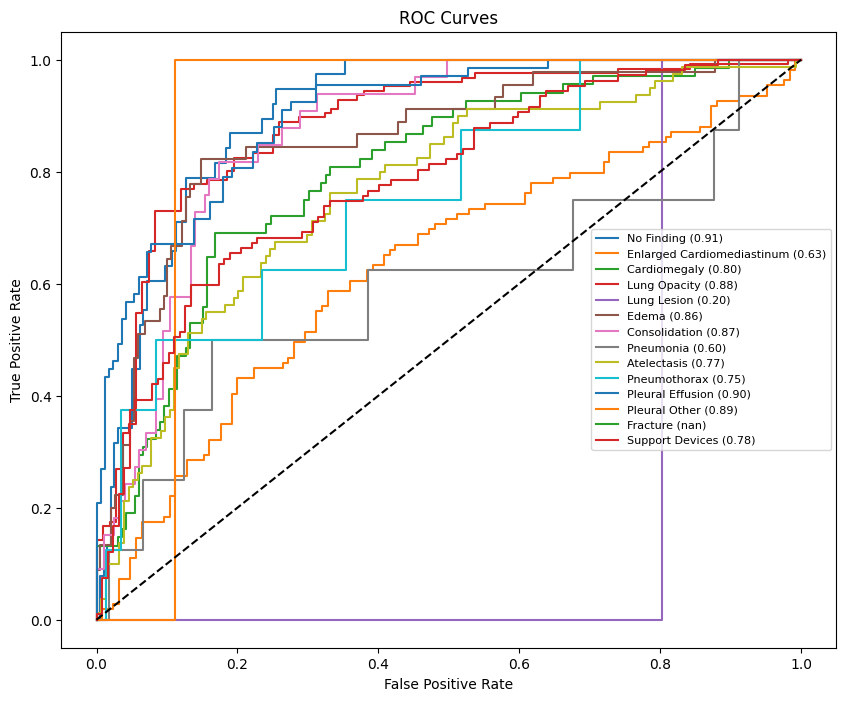

In [ ]:
plt.figure(figsize=(10,8))
for i in range(len(label_cols)):
    try:
        fpr,tpr,_ = roc_curve(
            targets[:,i],
            predictions[:,i]
        )
        plt.plot(
            fpr,
            tpr,
            label=f"{label_cols[i]} ({aurocs[i]:.2f})"
        )
    except:
        pass

plt.plot([0,1],[0,1],'k--')
plt.legend(fontsize=8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.show()

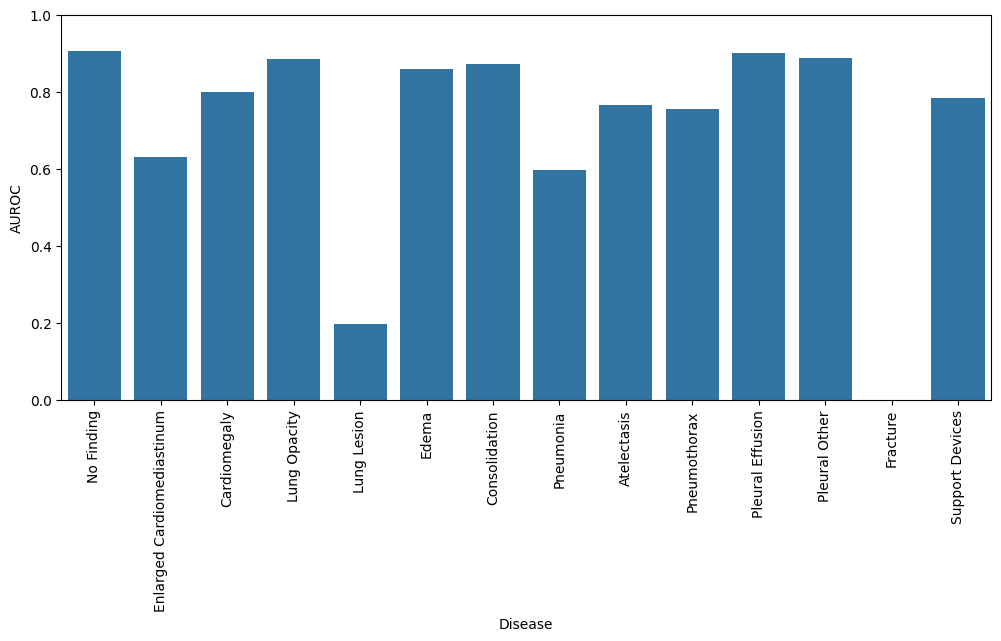

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(data=results,x="Disease",y="AUROC")

plt.xticks(rotation=90)
plt.ylim(0,1)
plt.show()

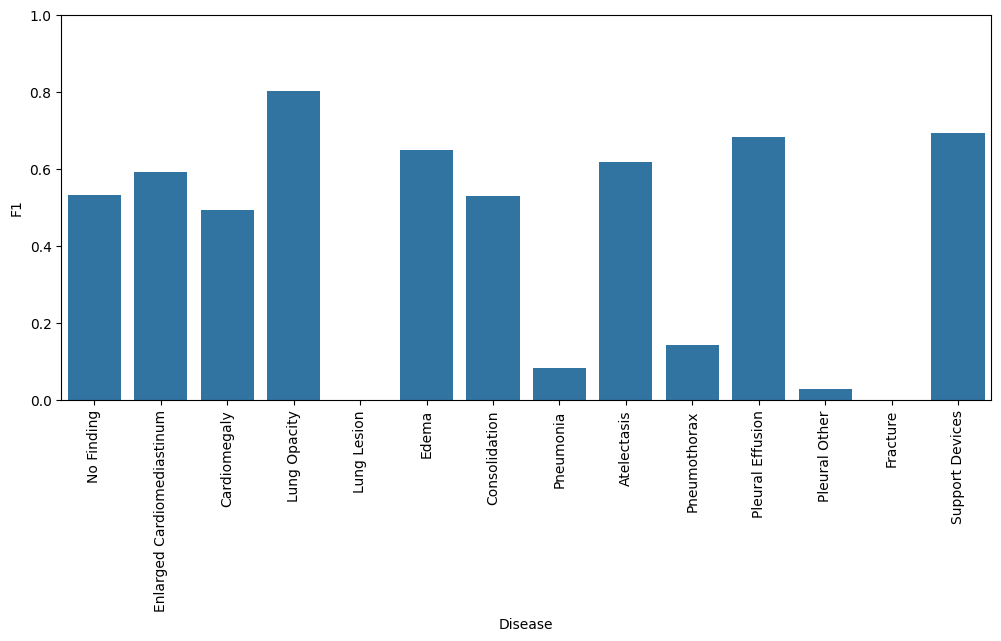

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(data=results,x="Disease",y="F1")
plt.xticks(rotation=90)
plt.ylim(0,1)
plt.show()

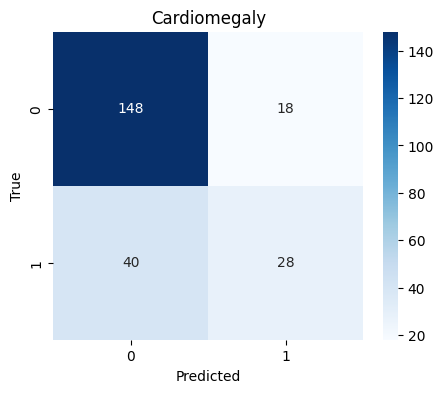

In [ ]:
idx = label_cols.index("Cardiomegaly")
cm = confusion_matrix(targets[:,idx],pred_binary[:,idx])

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Cardiomegaly")
plt.show()

In [ ]:
results.to_csv("CheXpert_BioMedCLIP_results.csv",index=False)
print(results)

                       Disease     AUROC        F1
0                   No Finding  0.905747  0.532374
1   Enlarged Cardiomediastinum  0.629945  0.591928
2                 Cardiomegaly  0.799167  0.491228
3                 Lung Opacity  0.884259  0.801724
4                  Lung Lesion  0.197425  0.000000
5                        Edema  0.857731  0.649123
6                Consolidation  0.870496  0.529412
7                    Pneumonia  0.597345  0.081633
8                  Atelectasis  0.765666  0.617021
9                 Pneumothorax  0.754978  0.142857
10            Pleural Effusion  0.901332  0.680851
11               Pleural Other  0.888412  0.026667
12                    Fracture       NaN  0.000000
13             Support Devices  0.784090  0.693069


#Fine Tuning

In [100]:
for param in model.parameters():
    param.requires_grad = True

print("All BioMedCLIP parameters are trainable.")

All BioMedCLIP parameters are trainable.


In [101]:
NUM_CLASSES = len(label_cols)

classifier = nn.Sequential(
    nn.Linear(512, 1024),
    nn.BatchNorm1d(1024),
    nn.GELU(),
    nn.Dropout(0.30),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.GELU(),
    nn.Dropout(0.20),
    nn.Linear(512, NUM_CLASSES)
).to(device)

In [103]:
import torch.optim as optim
optimizer = optim.AdamW(
    list(model.parameters()) + list(classifier.parameters()),
    lr=1e-5,weight_decay=1e-4)

In [104]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=20)

In [105]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))